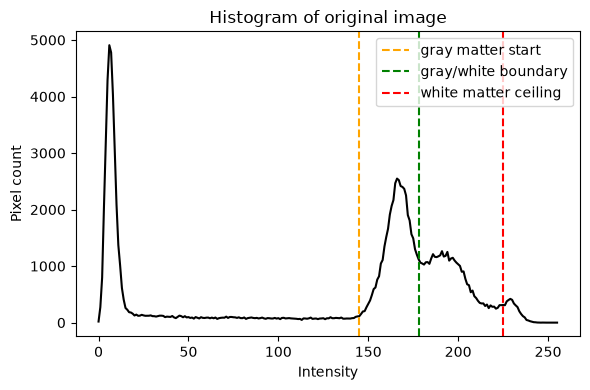

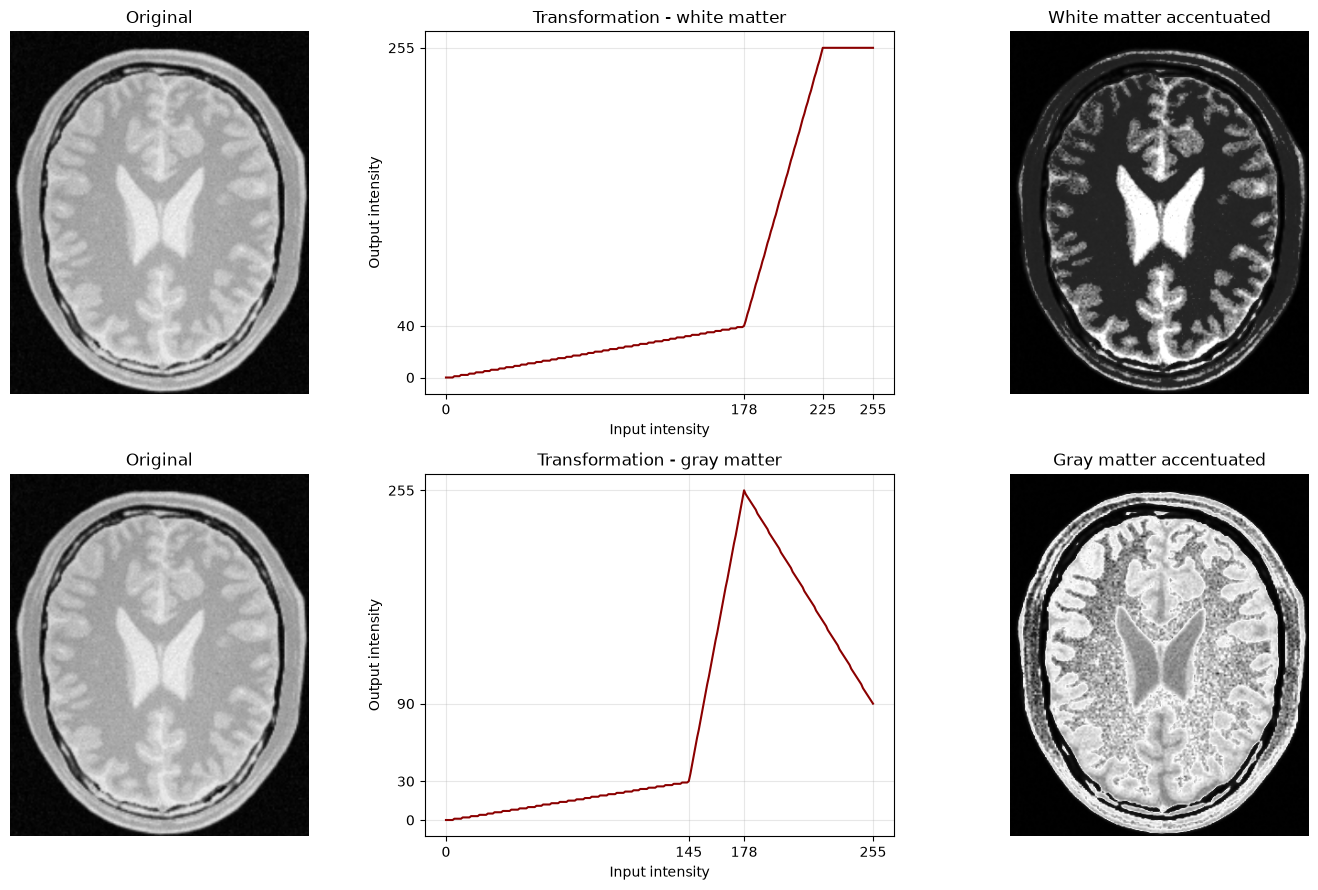

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
  x = breakpoints[:,0].astype(int)
  y = breakpoints[:,1].astype(int)

  c1 = np.linspace(y[0], y[1], x[1]-x[0]+1)
  c2 = np.linspace(y[2], y[3], x[3]-x[2]+1)
  c3 = np.linspace(y[4], y[5], x[5]-x[4]+1)

  piecewise_func = np.concatenate((c1, c2[1:], c3[1:]), axis=0)

  lut = np.clip(piecewise_func, 0, 255).astype(np.uint8)
  transformed = cv.LUT(im, lut)
  return transformed, lut

im = cv.imread(r'D:\Image processing and Computer Vision\Images\brain.png', cv.IMREAD_GRAYSCALE)
assert im is not None

hist = cv.calcHist([im], [0], None, [256], [0, 256]).flatten()

plt.figure(figsize=(6, 4))
plt.plot(hist, color="black")
plt.axvline(145, color="orange", linestyle="--", label="gray matter start")
plt.axvline(178, color="green", linestyle="--", label="gray/white boundary")
plt.axvline(225, color="red", linestyle="--", label="white matter ceiling")
plt.title("Histogram of original image")
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.legend()
plt.tight_layout()
plt.show()

breakpoints_white = np.array([
    [0,   0],
    [178, 40],
    [178, 40],
    [225, 255],
    [225, 255],
    [255, 255],
], dtype=np.float32)
white_img, lut_white = intensity_transform(im, breakpoints_white)

breakpoints_gray = np.array([
    [0,   0],
    [145, 30],
    [145, 30],
    [178, 255],
    [178, 255],
    [255, 90],
], dtype=np.float32)
gray_img, lut_gray = intensity_transform(im, breakpoints_gray)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(im, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].plot(np.arange(256), lut_white, color="darkred")
axes[0, 1].set_title("Transformation - white matter")
axes[0, 1].set_xlabel("Input intensity")
axes[0, 1].set_ylabel("Output intensity")
axes[0, 1].set_xticks(sorted(set(breakpoints_white[:, 0].astype(int))))
axes[0, 1].set_yticks(sorted(set(breakpoints_white[:, 1].astype(int))))
axes[0, 1].grid(alpha=0.3)

axes[0, 2].imshow(white_img, cmap="gray", vmin=0, vmax=255)
axes[0, 2].set_title("White matter accentuated")
axes[0, 2].axis("off")

axes[1, 0].imshow(im, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Original")
axes[1, 0].axis("off")

axes[1, 1].plot(np.arange(256), lut_gray, color="darkred")
axes[1, 1].set_title("Transformation - gray matter")
axes[1, 1].set_xlabel("Input intensity")
axes[1, 1].set_ylabel("Output intensity")
axes[1, 1].set_xticks(sorted(set(breakpoints_gray[:, 0].astype(int))))
axes[1, 1].set_yticks(sorted(set(breakpoints_gray[:, 1].astype(int))))
axes[1, 1].grid(alpha=0.3)

axes[1, 2].imshow(gray_img, cmap="gray", vmin=0, vmax=255)
axes[1, 2].set_title("Gray matter accentuated")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()